# Temporal Analysis of Uber Ride Demand and Urban Mobility Patterns

## Author
Tharushi Karunarathne

## Objective
This project investigates Uber trip demand patterns during September 2014. The analysis focuses on identifying peak travel periods, rider behavior trends, and operational insights that could support decision-making in ride-sharing services.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## Data Collection

The dataset contains Uber trip records from September 2014, including pickup timestamps, location coordinates, and Uber base information.

In [7]:
# Load dataset
df = pd.read_csv("../data/uber-raw-data-sep14.csv")

df.head()

,Date/Time,Lat,Lon,Base
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512


## Initial Data Exploration

Before performing analysis, the dataset is inspected to understand its structure, dimensions, and available attributes.

In [8]:
# Basic information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 1028136
Columns: 4
<class 'pandas.DataFrame'>
RangeIndex: 1028136 entries, 0 to 1028135
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Date/Time  1028136 non-null  str    
 1   Lat        1028136 non-null  float64
 2   Lon        1028136 non-null  float64
 3   Base       1028136 non-null  str    
dtypes: float64(2), str(2)
memory usage: 31.4 MB


In [9]:
# Summary statistics
df.describe()

,Lat,Lon
count,1.028136e+06,1.028136e+06
mean,4.073922e+01,-7.397182e+01
std,4.082861e-02,5.831413e-02
min,3.998970e+01,-7.477360e+01
25%,4.072040e+01,-7.399620e+01
50%,4.074180e+01,-7.398310e+01
75%,4.076120e+01,-7.396280e+01
max,4.134760e+01,-7.271630e+01


## Data Cleaning

Data quality checks are performed to identify missing values, duplicates, and formatting issues.

In [10]:
# Check missing values
df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

In [11]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 24037


In [12]:
df["Date/Time"] = pd.to_datetime(
    df["Date/Time"],
    errors="coerce"
)

print(df["Date/Time"].dtype)

datetime64[us]


## Feature Engineering

New variables such as hour, day, weekday, and trip categories are extracted from the timestamp to support time-based analysis.

In [13]:
# Feature engineering
df["hour"] = df["Date/Time"].dt.hour
df["day"] = df["Date/Time"].dt.day
df["weekday"] = df["Date/Time"].dt.day_name()
df["month"] = df["Date/Time"].dt.month_name()
df["minute"] = df["Date/Time"].dt.minute

df["day_type"] = np.where(
    df["weekday"].isin(["Saturday", "Sunday"]),
    "Weekend",
    "Weekday"
)

def classify_time_period(hour):
    if 6 <= hour <= 10:
        return "Morning Rush"
    elif 11 <= hour <= 15:
        return "Midday"
    elif 16 <= hour <= 20:
        return "Evening Rush"
    else:
        return "Off-Peak"

df["time_period"] = df["hour"].apply(classify_time_period)

df.head()

,Date/Time,Lat,Lon,Base,hour,day,weekday,month,minute,day_type,time_period
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512,0,1,Monday,September,1,Weekday,Off-Peak
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512,0,1,Monday,September,1,Weekday,Off-Peak
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512,0,1,Monday,September,3,Weekday,Off-Peak
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512,0,1,Monday,September,6,Weekday,Off-Peak
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512,0,1,Monday,September,11,Weekday,Off-Peak


## Analysis 1: Hourly Demand Patterns

This analysis explores how Uber demand changes throughout the day and identifies the busiest travel hours.

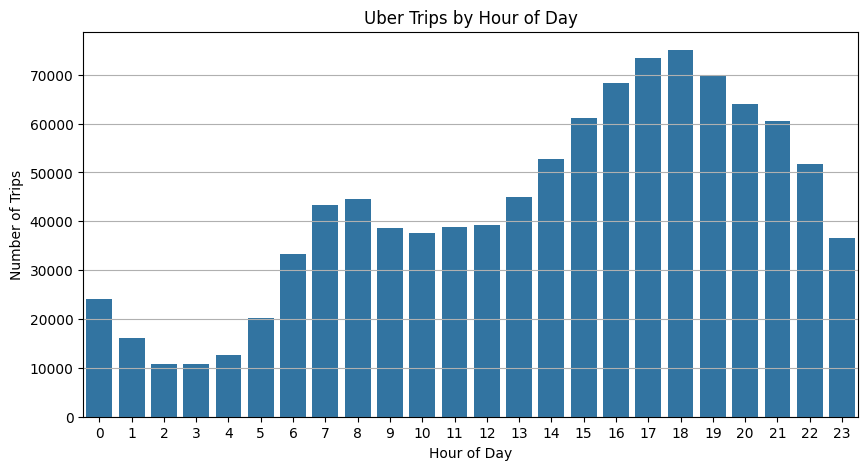

In [14]:
# Trips by hour
hourly_trips = df.groupby("hour").size()

sns.barplot(x=hourly_trips.index, y=hourly_trips.values)
plt.title("Uber Trips by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.savefig("../images/hourly_demand.png", bbox_inches="tight")
plt.show()

### Observation

The highest trip volumes occur during evening hours, indicating strong demand from commuters and leisure travelers.

In [15]:
# Top 5 busiest hours
hourly_trips.sort_values(ascending=False).head()

hour
18    75040
17    73373
19    69660
16    68224
20    63988
dtype: int64

## Analysis 2: Weekday Demand Analysis

This section investigates how demand varies across different days of the week.

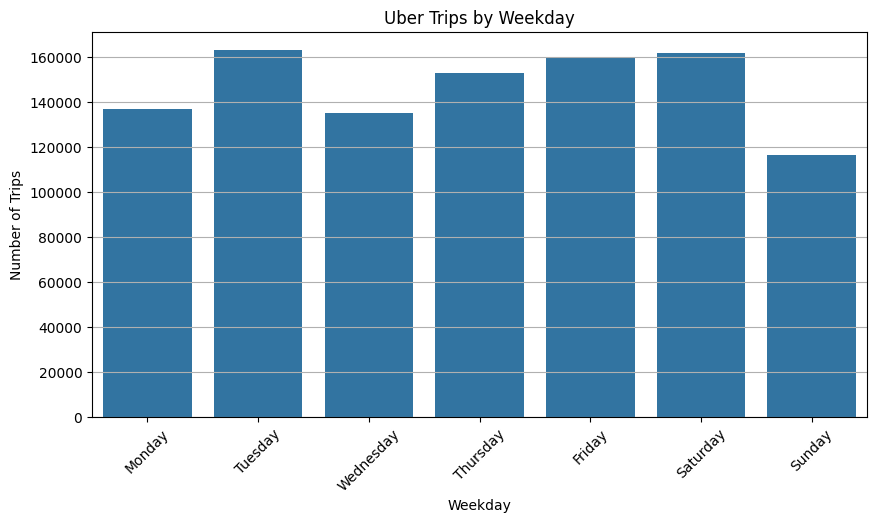

In [16]:
# Trips by weekday
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_trips = df["weekday"].value_counts().reindex(weekday_order)

sns.barplot(x=weekday_trips.index, y=weekday_trips.values)
plt.title("Uber Trips by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.savefig("../images/weekday_demand.png", bbox_inches="tight")
plt.show()

### Observation

Trip demand tends to increase toward the end of the week, with Friday and Saturday recording higher activity levels.

In [17]:
weekday_trips.sort_values(ascending=False)

weekday
Tuesday      163230
Saturday     162057
Friday       160380
Thursday     153276
Monday       137288
Wednesday    135373
Sunday       116532
Name: count, dtype: int64

## Analysis 3: Daily Demand Trends

This analysis examines fluctuations in Uber demand throughout September 2014.

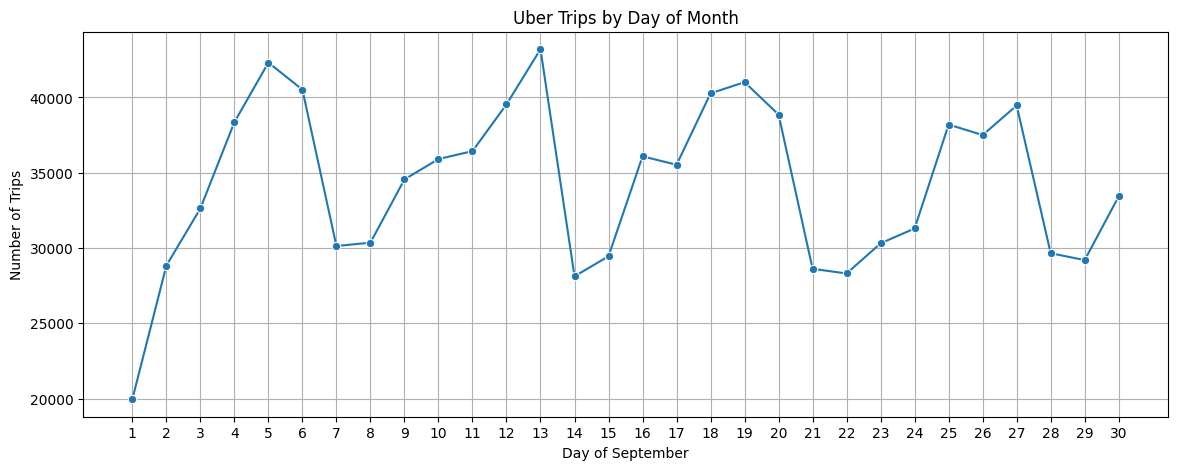

In [18]:
# Trips by day of month
daily_trips = df.groupby("day").size()

plt.figure(figsize=(14, 5))
sns.lineplot(x=daily_trips.index, y=daily_trips.values, marker="o")
plt.title("Uber Trips by Day of Month")
plt.xlabel("Day of September")
plt.ylabel("Number of Trips")
plt.xticks(range(1, 31))
plt.savefig("../images/daily_demand.png", bbox_inches="tight")
plt.show()

In [19]:
# Top 10 busiest dates
daily_trips.sort_values(ascending=False).head(10)

day
13    43205
5     42319
19    41017
6     40520
18    40274
12    39540
27    39468
20    38864
4     38360
25    38203
dtype: int64

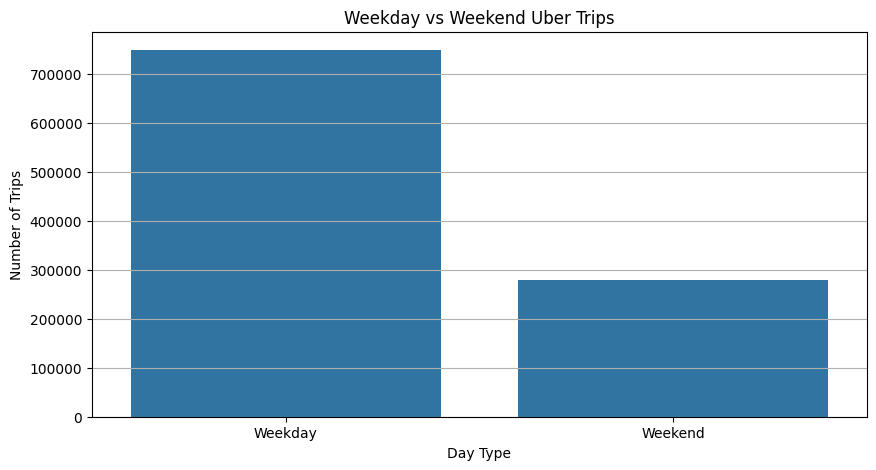

In [20]:
# Weekday vs weekend
day_type_trips = df["day_type"].value_counts()

sns.barplot(x=day_type_trips.index, y=day_type_trips.values)
plt.title("Weekday vs Weekend Uber Trips")
plt.xlabel("Day Type")
plt.ylabel("Number of Trips")
plt.show()

In [21]:
day_type_trips

day_type
Weekday    749547
Weekend    278589
Name: count, dtype: int64

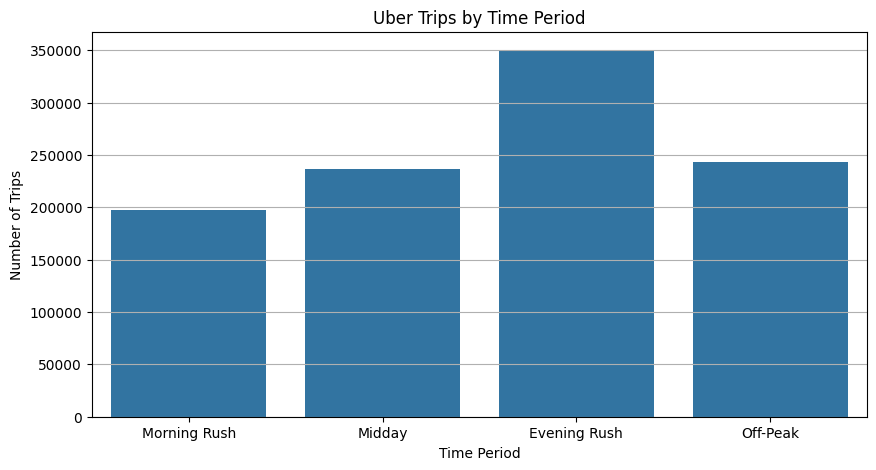

In [22]:
# Trips by time period
time_period_order = [
    "Morning Rush",
    "Midday",
    "Evening Rush",
    "Off-Peak"
]

time_period_trips = df["time_period"].value_counts().reindex(time_period_order)

sns.barplot(x=time_period_trips.index, y=time_period_trips.values)
plt.title("Uber Trips by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Number of Trips")
plt.show()

In [23]:
time_period_trips

time_period
Morning Rush    197274
Midday          236918
Evening Rush    350285
Off-Peak        243659
Name: count, dtype: int64

## Analysis 4: Demand Heatmap

A heatmap is used to visualize ride demand across weekdays and hours simultaneously.

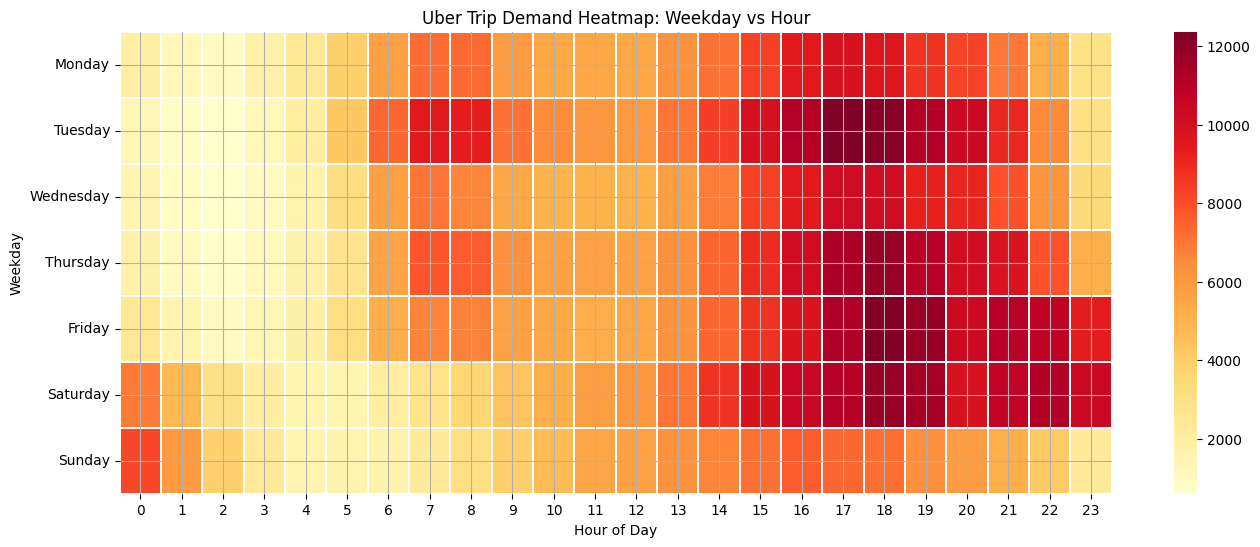

In [24]:
# Heatmap: weekday vs hour
heatmap_data = pd.crosstab(df["weekday"], df["hour"])
heatmap_data = heatmap_data.reindex(weekday_order)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.3)

plt.title("Uber Trip Demand Heatmap: Weekday vs Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday")
plt.savefig("../images/demand_heatmap.png", bbox_inches="tight")
plt.show()

### Observation

The heatmap highlights clear peak-demand periods during afternoon and evening hours. Demand intensity varies across weekdays, suggesting that rider behavior is influenced by both work-related and leisure activities.

## Analysis 5: Top Demand Hours

To better understand rider behavior, the five busiest hours were identified and compared with overall demand patterns.

In [25]:
top_hours = hourly_trips.sort_values(ascending=False).head(5)

print("Top 5 busiest hours:")
print(top_hours)

Top 5 busiest hours:
hour
18    75040
17    73373
19    69660
16    68224
20    63988
dtype: int64


### Observation

The results show that ride demand is concentrated within a small number of peak hours. These periods likely represent a combination of commuting activity and evening travel demand.

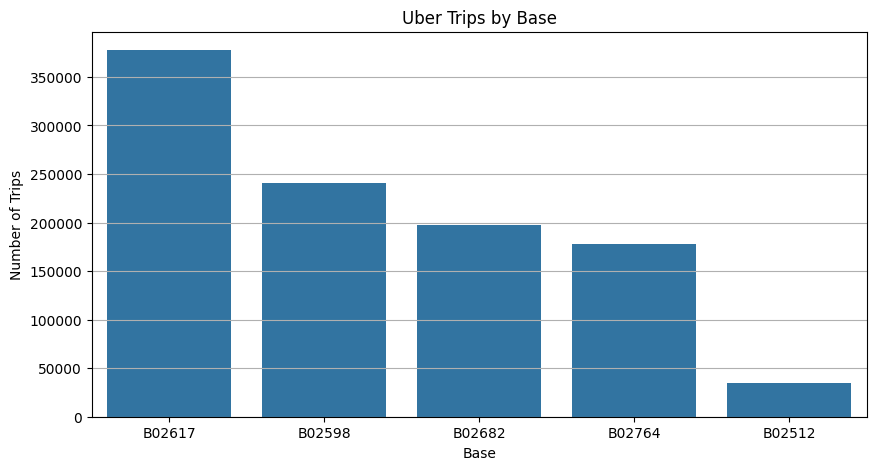

In [26]:
# Trips by Uber base
base_trips = df["Base"].value_counts()

sns.barplot(x=base_trips.index, y=base_trips.values)
plt.title("Uber Trips by Base")
plt.xlabel("Base")
plt.ylabel("Number of Trips")
plt.show()

In [27]:
base_trips

Base
B02617    377695
B02598    240600
B02682    197138
B02764    178333
B02512     34370
Name: count, dtype: int64

## Analysis 6: Spatial Distribution of Pickups

Pickup coordinates are visualized to identify areas with concentrated ride activity.

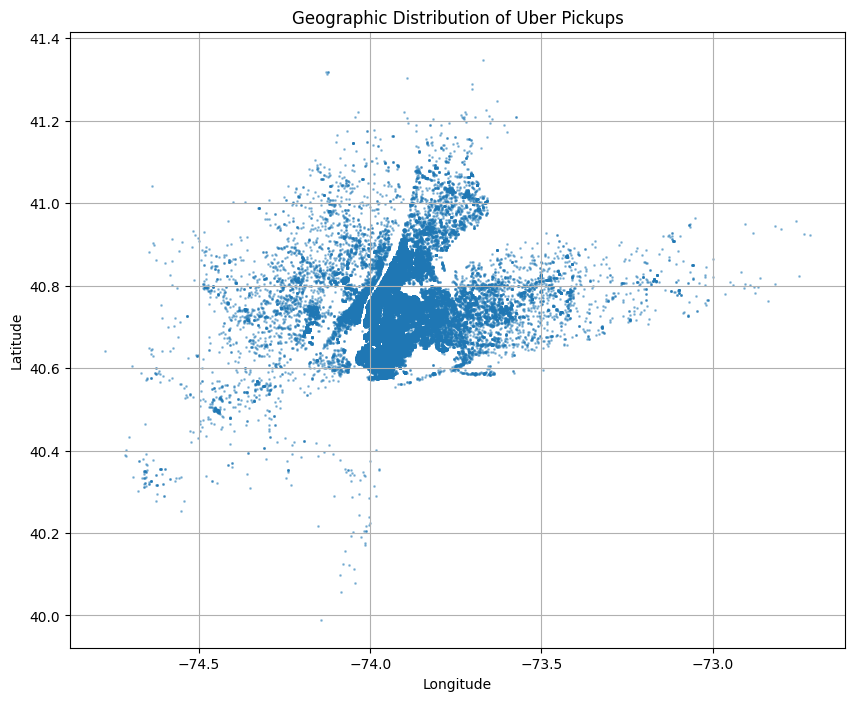

In [28]:
# Geographic distribution of pickups
plt.figure(figsize=(10, 8))
plt.scatter(df["Lon"], df["Lat"], s=1, alpha=0.4)

plt.title("Geographic Distribution of Uber Pickups")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("../images/pickup_locations.png", bbox_inches="tight")
plt.show()

### Observation

Pickup locations are highly concentrated within urban areas, indicating that Uber demand is strongest in densely populated regions with higher levels of economic and social activity.

In [29]:
# Final summary values
print("Total trips:", len(df))
print("Busiest hour:", hourly_trips.idxmax())
print("Busiest weekday:", weekday_trips.idxmax())
print("Busiest day of month:", daily_trips.idxmax())
print("Most active base:", base_trips.idxmax())

Total trips: 1028136
Busiest hour: 18
Busiest weekday: Tuesday
Busiest day of month: 13
Most active base: B02617


In [30]:
print("Total Trips:", len(df))
print("Number of Uber Bases:", df["Base"].nunique())
print("Average Trips per Day:", round(len(df) / 30))

Total Trips: 1028136
Number of Uber Bases: 5
Average Trips per Day: 34271


## Summary Statistics

The dataset contains over one million Uber trip records collected during September 2014. The analysis was conducted using time-based feature engineering and exploratory data analysis techniques to identify demand patterns and operational insights.

# Conclusions

## Key Findings

1. Uber demand varies significantly throughout the day.
2. Evening hours experience the highest ride volume.
3. Weekday demand patterns differ from weekend behavior.
4. The heatmap highlights recurring peak-demand periods.
5. Most pickups are concentrated in densely populated urban areas.

## Business Recommendations

- Increase driver availability during peak evening hours.
- Optimize resource allocation based on weekday demand patterns.
- Use historical demand data to support forecasting and operational planning.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [31]:
# Export processed dataset for Tableau

tableau_df = df.copy()

tableau_df.to_csv(
    "uber_tableau_dataset.csv",
    index=False
)

print("Export successful!")

Export successful!
